# MMM Model Fitting

Fits a Bayesian Marketing Mix Model and validates it against the true
channel parameters embedded in the synthetic dataset.

**Modeling note:** the synthetic sales process combines trend, seasonality,
and price effects multiplicatively. An additive-baseline model without an
explicit trend term inflated channel contributions 100-280% vs ground
truth (relative ranking stayed accurate). Adding a `time_trend` control
column corrected this.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

df = pd.read_csv('../data/raw/mmm_weekly_data.csv', parse_dates=['date'])
contributions_true = pd.read_csv('../data/processed/true_contributions.csv')

channels = ['tv_spend', 'paid_search_spend', 'paid_social_spend', 'display_spend', 'promo_spend']
df['time_trend'] = np.arange(len(df)) / len(df)

In [2]:
from pymc_marketing.mmm import MMM
from pymc_marketing.mmm.components.adstock import GeometricAdstock
from pymc_marketing.mmm.components.saturation import LogisticSaturation

mmm = MMM(
    date_column='date',
    channel_columns=channels,
    control_columns=['price_index', 'time_trend'],
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    target_column='sales',
)

X = df[['date'] + channels + ['price_index', 'time_trend']]
y = df['sales']

mmm.fit(X, y.values, target_accept=0.98, chains=4, draws=1500, tune=1500, random_seed=42)

g++ not available, if using conda: `conda install gxx`
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 186 seconds.
There were 34 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         eebddbf57febc146
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 4, draw: 1500, channel: 5,
│                                                     fourier_mode: 4, control: 2,
│                                                     date: 156)
│       Coordinates:
│         * chain                                    (chain) int64 32B 0 1 2 3
│         * draw                                     (draw) int64 12kB 0 1 ... 1498 1499
│         * channel                                  (channel) <U17 340B 'tv_spend' ....
│         * fourier_mode                             (fourier_mode) <U5 80B 'sin_1' ....
│         * control                                  (control) <U11 88B 'price_index'...
│         * date                                     (date) datetime64[us] 1kB 2022-0...
│       Data variables:
│           adstock_alpha                            (chain, draw, channel) float64 240kB ...
│           saturation_lam                           (chain, draw, channel) float64 240kB ...
│           saturation_beta                          (chain, draw, channel) float64 240kB ...
│           gamma_fourier                            (chain, draw, fourier_mode) float64 192kB ...
│           gamma_control                            (chain, draw, control) float64 96kB ...
│           y_sigma                                  (chain, draw) float64 48kB 0.042...
│           intercept_contribution                   (chain, draw) float64 48kB 1.204...
│           total_media_contribution_original_scale  (chain, draw) float64 48kB 1.783...
│           yearly_seasonality_contribution          (chain, draw, date) float64 7MB ...
│           fourier_contribution                     (chain, draw, date, fourier_mode) float64 30MB ...
│           control_contribution                     (chain, draw, date, control) float64 15MB ...
│           channel_contribution                     (chain, draw, date, channel) float64 37MB ...
│       Attributes:
│           created_at:                 2026-08-18T13:19:30.125172+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              185.79483008384705
│           tuning_steps:               1500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1500)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 12kB 0 1 2 3 4 ... 1496 1497 1498 1499
│       Data variables: (12/18)
│           reached_max_treedepth  (chain, draw) bool 6kB False False ... False False
│           smallest_eigval        (chain, draw) float64 48kB nan nan nan ... nan nan
│           lp                     (chain, draw) float64 48kB 204.6 202.8 ... 209.8
│           diverging              (chain, draw) bool 6kB False False ... False False
│           max_energy_error       (chain, draw) float64 48kB 0.06606 ... -0.04239
│           energy                 (chain, draw) float64 48kB -198.6 -192.1 ... -200

In [3]:
divergences = mmm.idata.sample_stats.diverging.sum().item()
print(f"Total divergences: {divergences}")
print(az.summary(mmm.idata, var_names=['adstock_alpha', 'saturation_lam', 'saturation_beta', 'y_sigma']))

Total divergences: 34
                                      mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
adstock_alpha[tv_spend]              0.407    0.231    0.049     0.77     3397     3418  1.00    0.0039   0.0019
adstock_alpha[paid_search_spend]     0.372    0.249    0.031     0.78     3136     3246  1.00    0.0045   0.0021
adstock_alpha[paid_social_spend]     0.458    0.251    0.056     0.83     3696     3378  1.00    0.0041   0.0019
adstock_alpha[display_spend]         0.323    0.252    0.019      0.8     4501     2989  1.00    0.0038   0.0022
adstock_alpha[promo_spend]            0.51    0.305    0.045     0.92     2411     3404  1.00    0.0064   0.0025
saturation_lam[tv_spend]              3.58      2.4     0.62      8.1     2531     2460  1.00     0.048    0.038
saturation_lam[paid_search_spend]      4.1     2.61     0.69      8.8     1985     2283  1.00     0.056     0.04
saturation_lam[paid_social_spend]     2.86     2.05     0.52      6.7     

In [4]:
# Use mmm.save() rather than manual to_netcdf — this is the format MMM.load() expects,
# and overwrites cleanly without needing a manual delete step
mmm.save('../data/processed/mmm_fit.nc')
print("Saved.")

Saved.


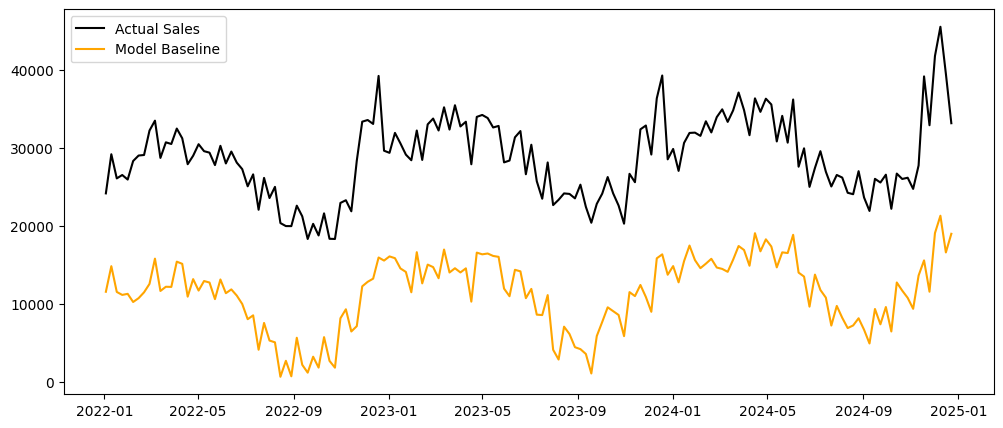

In [5]:
target_scale = mmm.idata.constant_data['target_scale'].item()

baseline_est = (
    mmm.idata.posterior['intercept_contribution'].mean(dim=['chain','draw']).item() +
    mmm.idata.posterior['yearly_seasonality_contribution'].mean(dim=['chain','draw']).values +
    mmm.idata.posterior['control_contribution'].mean(dim=['chain','draw']).sum(dim='control').values
) * target_scale

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], df['sales'], label='Actual Sales', color='black')
ax.plot(df['date'], baseline_est, label='Model Baseline', color='orange')
ax.legend()
plt.savefig('../outputs/charts/baseline_vs_actual.png', dpi=100)
plt.show()

In [6]:
contributions_posterior = mmm.idata.posterior['channel_contribution'].mean(dim=['chain', 'draw'])
contributions_estimated = contributions_posterior.to_pandas()
contributions_estimated.columns = channels
contributions_estimated_original_scale = contributions_estimated * target_scale

comparison = pd.DataFrame({
    'channel': channels,
    'true_total_contribution': [contributions_true[ch.replace('_spend','')].sum() for ch in channels],
    'estimated_total_contribution': contributions_estimated_original_scale.sum().values,
})
comparison['pct_difference'] = (comparison['estimated_total_contribution'] - comparison['true_total_contribution']) / comparison['true_total_contribution'] * 100
comparison['true_share_of_media'] = comparison['true_total_contribution'] / comparison['true_total_contribution'].sum()
comparison['estimated_share_of_media'] = comparison['estimated_total_contribution'] / comparison['estimated_total_contribution'].sum()
comparison

,channel,true_total_contribution,estimated_total_contribution,pct_difference,true_share_of_media,estimated_share_of_media
0,tv_spend,240707.616558,920962.685886,282.606375,0.299677,0.339139
1,paid_search_spend,251240.351059,951040.417683,278.538087,0.312790,0.350215
2,paid_social_spend,182280.230824,451886.782892,147.907730,0.226936,0.166404
3,display_spend,56616.814498,118832.779496,109.889554,0.070487,0.043759
4,promo_spend,72378.017379,272871.278015,277.008501,0.090109,0.100483


In [7]:
spend_totals = df[channels].sum()
spend_share = spend_totals / spend_totals.sum()

efficiency = pd.DataFrame({
    'channel': channels,
    'spend_share': spend_share.values,
    'contribution_share': comparison['estimated_share_of_media'].values,
})
efficiency['efficiency_index'] = efficiency['contribution_share'] / efficiency['spend_share']
efficiency = efficiency.sort_values('efficiency_index', ascending=False)

comparison.to_csv('../data/processed/channel_comparison.csv', index=False)
efficiency.to_csv('../data/processed/channel_efficiency.csv', index=False)
efficiency

,channel,spend_share,contribution_share,efficiency_index
1,paid_search_spend,0.249499,0.350215,1.403672
4,promo_spend,0.072248,0.100483,1.390803
0,tv_spend,0.383493,0.339139,0.884340
2,paid_social_spend,0.198065,0.166404,0.840151
3,display_spend,0.096695,0.043759,0.452552
